# Exercise 3

Dataset: `Lab1_Ex3_BDS_TPHCM.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Load data (try local path first, then fallback to the provided file path)
candidate_paths = [
    'Lab1_Ex3_BDS_TPHCM.csv',
    os.path.join('/mnt/data', 'Lab1_Ex3_BDS_TPHCM.csv'),
]
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break
else:
    raise FileNotFoundError('Cannot find Lab1_Ex3_BDS_TPHCM.csv')

df = pd.read_csv(data_path)
df.head()


,Phòng ăn,Pháp lý,addressLocality,Số phòng ngủ,price_text,Chính chủ,addressRegion,Đường trước nhà,description,Chiều dài,streetAddress,Sân thượng,Thuộc dự án,Hướng,title,Loại BDS,Nhà bếp,Chiều ngang,price_value,area,Loại tin,Mã tin,Chổ để xe hơi,Số lầu,address_old
0,NaN,Sổ hồng/ Sổ đỏ,Xã Cần Giờ,NaN,"3,3 tỷ",NaN,Hồ Chí Minh,8m,Diện tích 4.5 x 22 m\r\n Cần bán gấp kinh...,22m,Đường Lương Văn Nho,NaN,NaN,NaN,Bán đất Đường Lương Văn Nho Cần giờ 100m2 giá ...,"Đất thổ cư, đất ở",NaN,"4,5m",3300000000,95.0,Cần bán,17404932,NaN,NaN,"Đường Lương Văn Nho, Xã Long Hòa, Huyện Cần Gi..."
1,NaN,Giấy tờ hợp lệ,Xã Cần Giờ,3.0,20 tỷ,NaN,Hồ Chí Minh,14m,PHÂN KHU B – VINHOMES GREEN PARADISE CẦN GIỜ 🌴...,15m,Đường Duyên Hải,NaN,Khu biệt thự Vinpearl Cần Giờ Resort & Villas(...,NaN,NHẬN BOOKING DỰ ÁN VINHOMES CẦN GIỜ TỪ HÔM NAY...,"Biệt thự, nhà liền kề",NaN,10m,20000000000,150.0,Cần bán,17466534,NaN,1,"Đường Duyên Hải, Xã Long Hòa, Huyện Cần Giờ, H..."
2,NaN,Sổ hồng/ Sổ đỏ,Xã Cần Giờ,1.0,16 triệu / m²,NaN,Hồ Chí Minh,20m,🏞️ TIN 4: BÁN ĐẤT VIEW ĐẸP SÁT VINHOMES CẦN GI...,120m,Đường Thạnh Thới,NaN,NaN,NaN,"Bán đất lớn 12.031,8m² sát khu Vinhomes Green ...",Nhà mặt tiền,NaN,100m,192000000000,12.0,Cần bán,17686301,NaN,1,"Đường Thạnh Thới, Xã Long Hòa, Huyện Cần Giờ, ..."
3,NaN,Sổ hồng/ Sổ đỏ,Xã Cần Giờ,1.0,16 triệu / m²,NaN,Hồ Chí Minh,20m,🌿 TIN 3: CƠ HỘI VÀNG – SỞ HỮU 12.000M² ĐẤT GẦN...,120m,Đường Nguyễn Văn Mạnh,NaN,NaN,NaN,"Đất 12.031,8m² gần Vinhomes Cần Giờ – View đẹp...",Nhà mặt tiền,NaN,100m,192000000000,12.0,Cần bán,17686317,NaN,1,"Đường Nguyễn Văn Mạnh, Xã Long Hòa, Huyện Cần ..."
4,NaN,Sổ hồng/ Sổ đỏ,Xã Cần Giờ,1.0,16 triệu / m²,NaN,Hồ Chí Minh,16m,🌊 TIN 2: ĐẤT THỔ CƯ GẦN VINHOMES GREEN PARADIS...,100m,Đường Nguyễn Văn Mạnh,NaN,NaN,NaN,"Siêu lô đất 12.031,8m² (1.436m² thổ cư) cách V...",Nhà mặt tiền,NaN,120m,192000000000,12.0,Cần bán,17686452,NaN,1,"Đường Nguyễn Văn Mạnh, Xã Long Hòa, Huyện Cần ..."


*9. How many rows and columns does the dataset have?*

In [2]:
df.shape

(13700, 25)

**Answer:** The dataset contains **13700 rows** and **25 columns**.

*10. Which columns are numeric?*

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['Phòng ăn',
 'Số phòng ngủ',
 'Chính chủ',
 'Sân thượng',
 'Nhà bếp',
 'price_value',
 'area',
 'Mã tin',
 'Chổ để xe hơi']

**Answer:** Numeric columns are shown above (based on pandas dtypes).

*11. Which columns are categorical?*

In [4]:
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
categorical_cols

['Pháp lý',
 'addressLocality',
 'price_text',
 'addressRegion',
 'Đường trước nhà',
 'description',
 'Chiều dài',
 'streetAddress',
 'Thuộc dự án',
 'Hướng',
 'title',
 'Loại BDS',
 'Chiều ngang',
 'Loại tin',
 'Số lầu',
 'address_old']

**Answer:** Categorical columns are shown above (based on pandas dtypes).

*12. How many listings are there for each property type (Loại BDS)?*

In [5]:
df['Loại BDS'].value_counts(dropna=False)

Loại BDS
Nhà trong hẻm                  5744
Nhà mặt tiền                   5143
Đất thổ cư, đất ở              1501
Biệt thự, nhà liền kề           515
Văn phòng                       158
Kho, xưởng                      131
Đất nông, lâm nghiệp            123
Nhà hàng, khách sạn             115
Phòng trọ, nhà trọ              104
Đất nền, liền kề, đất dự án      81
Căn hộ chung cư                  74
Trang trại                        6
Mặt bằng                          2
Các loại khác                     2
Shop, kiot, quán                  1
Name: count, dtype: int64

**Answer:** The table above shows the number of listings for each property type.

*13. What is the average property price?*

In [6]:
df['price_value'].describe()

count    1.370000e+04
mean     3.514545e+10
std      9.004663e+10
min      0.000000e+00
25%      6.500000e+09
50%      1.290000e+10
75%      3.200000e+10
max      4.999660e+12
Name: price_value, dtype: float64

**Answer:** Use the **mean** in the summary above as the average property price (VND).

*14. Check columns with missing values.*

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing>0]

Phòng ăn           13700
Chính chủ          13700
Chổ để xe hơi      13700
Nhà bếp            13700
Sân thượng         13700
Thuộc dự án        13529
Hướng              12450
Pháp lý             3680
Số lầu              2084
Chiều dài           2010
Chiều ngang         1803
Số phòng ngủ        1730
Đường trước nhà       41
dtype: int64

**Answer:** The output lists columns that contain missing values.

## Data Cleaning & Standardization (Requirement 2)

We will focus on: **Chiều dài, Chiều ngang, price_value, area** and also standardize `price_text` for checking.

*17. Standardize columns with units such as `m`, `m²` (Length, Width, area)*

Parse text like `"12 m"`, `"4.5m"`, `"60m²"` into clean numeric values (meters/meters²).


In [8]:
import re
import numpy as np
import pandas as pd

def parse_float_from_text(s: str):
    """Extract first float number from text (supports comma decimal)."""
    if s is None or (isinstance(s,float) and np.isnan(s)):
        return np.nan
    if isinstance(s,(int,float,np.integer,np.floating)) and not (isinstance(s,bool)):
        return float(s)
    t=str(s).strip().lower().replace('\xa0',' ')
    if t=='':
        return np.nan
    # keep digits, comma, dot, minus
    t=re.sub(r'[^0-9,\.\-]', '', t)
    if t in ('', '-', '.', ','):
        return np.nan
    # If both comma and dot: assume dot thousands, comma decimal (vi-VN)
    if ',' in t and '.' in t:
        t = t.replace('.', '').replace(',', '.')
    else:
        t = t.replace(',', '.')
    try:
        return float(t)
    except:
        return np.nan

def parse_number_with_units(x):
    """Parse numbers from strings that may include units like m, m2, m²."""
    if pd.isna(x):
        return np.nan
    if isinstance(x,(int,float,np.integer,np.floating)) and not isinstance(x,bool):
        return float(x)
    s=str(x).strip().lower().replace('\xa0',' ')
    if s=='':
        return np.nan
    # Remove common unit tokens
    s = s.replace('m²','').replace('m2','').replace('m','')
    return parse_float_from_text(s)

def parse_price_text(price_text, area_m2=None):
    """
    Standardize price_text (e.g., '3.3 tỷ', '16 triệu/m²', '1,2 billion') into:
    - total_vnd: total listing price in VND (if can infer)
    - per_m2_vnd: unit price VND/m² (if expressed per m²)
    """
    if price_text is None or (isinstance(price_text,float) and np.isnan(price_text)):
        return (np.nan, np.nan)
    s=str(price_text).strip().lower().replace('\xa0',' ')
    if s=='':
        return (np.nan, np.nan)
    # Negotiable / unknown
    if any(k in s for k in ['thoả thuận','thỏa thuận','liên hệ','call','contact','đang cập nhật']):
        return (np.nan, np.nan)

    # Detect per-m2
    per_m2 = bool(re.search(r'/(m2|m²)\b', s)) or ('/m2' in s) or ('/m²' in s)

    # Unit multipliers
    mult = 1.0
    if any(k in s for k in ['tỷ','ty','billion']):
        mult = 1e9
    elif any(k in s for k in ['triệu','trieu','million']):
        mult = 1e6
    elif any(k in s for k in ['nghìn','nghin','thousand','k']):
        mult = 1e3
    elif 'đ' in s or 'vnd' in s:
        mult = 1.0

    val = parse_float_from_text(s)
    if np.isnan(val):
        return (np.nan, np.nan)

    if per_m2:
        per_m2_vnd = val * mult
        total_vnd = per_m2_vnd * area_m2 if area_m2 is not None and not np.isnan(area_m2) else np.nan
        return (total_vnd, per_m2_vnd)
    else:
        total_vnd = val * mult
        per_m2_vnd = total_vnd / area_m2 if area_m2 is not None and not np.isnan(area_m2) and area_m2>0 else np.nan
        return (total_vnd, per_m2_vnd)

def extract_old_district(addr):
    """Extract old district from address_old."""
    if pd.isna(addr):
        return np.nan
    s = str(addr).replace('\xa0', ' ')
    if re.search(r'(thủ\s*đức|tp\.?\s*thủ\s*đức|thành\s*phố\s*thủ\s*đức)', s, flags=re.I):
        return 'Thành phố Thủ Đức'
    m = re.search(r'quận\s*(\d+)', s, flags=re.I)
    if m:
        return f'Quận {int(m.group(1))}'
    m = re.search(r'huyện\s*([^,]+)', s, flags=re.I)
    if m:
        return f'Huyện {m.group(1).strip()}'
    return np.nan

def extract_old_ward(addr):
    """Extract old ward/commune from address_old."""
    if pd.isna(addr):
        return np.nan
    s = str(addr).replace('\xa0', ' ')
    m = re.search(r'phường\s*([^,]+)', s, flags=re.I)
    if m:
        return f'Phường {m.group(1).strip()}'
    m = re.search(r'xã\s*([^,]+)', s, flags=re.I)
    if m:
        return f'Xã {m.group(1).strip()}'
    m = re.search(r'thị\s*trấn\s*([^,]+)', s, flags=re.I)
    if m:
        return f'Thị trấn {m.group(1).strip()}'
    return np.nan

df_clean = df.copy()

# (17) Standardize columns with units (Length, Width, area)
df_clean['length_m'] = df_clean['Chiều dài'].apply(parse_number_with_units)
df_clean['width_m']  = df_clean['Chiều ngang'].apply(parse_number_with_units)
df_clean['area_m2']   = df_clean['area'].apply(parse_number_with_units)

# price_value is expected to be total VND (already numeric-ish but may contain formatting)
df_clean['price_value_vnd'] = df_clean['price_value'].apply(parse_float_from_text)

# (15) Standardize price_text into numeric format (total and per-m2)
tmp = df_clean.apply(lambda r: parse_price_text(r['price_text'], r['area_m2']), axis=1, result_type='expand')
tmp.columns = ['price_text_total_vnd', 'price_text_per_m2_vnd']
df_clean = pd.concat([df_clean, tmp], axis=1)

# If price_value_vnd is missing but price_text_total_vnd is available, fill it (optional, but useful)
df_clean['price_filled_vnd'] = df_clean['price_value_vnd'].fillna(df_clean['price_text_total_vnd'])

# Old address fields extracted from address_old (used for comparison + grouping)
df_clean['old_district'] = df_clean['address_old'].apply(extract_old_district)
df_clean['old_ward']     = df_clean['address_old'].apply(extract_old_ward)

df_clean[['price_text','price_value','price_value_vnd','price_text_total_vnd','price_text_per_m2_vnd','price_filled_vnd','area_m2','length_m','width_m']].head()


,price_text,price_value,price_value_vnd,price_text_total_vnd,price_text_per_m2_vnd,price_filled_vnd,area_m2,length_m,width_m
0,"3,3 tỷ",3300000000,3.300000e+09,3.300000e+09,3.473684e+07,3.300000e+09,95.0,22.0,4.5
1,20 tỷ,20000000000,2.000000e+10,2.000000e+10,1.333333e+08,2.000000e+10,150.0,15.0,10.0
2,16 triệu / m²,192000000000,1.920000e+11,1.600000e+07,1.333333e+06,1.920000e+11,12.0,120.0,100.0
3,16 triệu / m²,192000000000,1.920000e+11,1.600000e+07,1.333333e+06,1.920000e+11,12.0,120.0,100.0
4,16 triệu / m²,192000000000,1.920000e+11,1.600000e+07,1.333333e+06,1.920000e+11,12.0,100.0,120.0


*15. Standardize the column `price_text` into numeric format*

Convert examples like `"3.3 tỷ"`, `"16 triệu/m²"` into numeric values:
- `price_text_total_vnd` (estimated total price in VND)
- `price_text_vnd_per_m2` (estimated VND/m² when the text is per m²)

### Validation: `price_text` vs `price_value`
After converting `price_text`, compare with `price_value` to detect inconsistencies and optionally fill missing values.


In [9]:
# How many prices can be parsed from price_text?
df_clean['price_text_total_vnd'].notna().mean(), df_clean['price_value_vnd'].notna().mean()

# Compare when both are available
both = df_clean.dropna(subset=['price_value_vnd','price_text_total_vnd']).copy()
both['abs_pct_diff'] = (both['price_value_vnd'] - both['price_text_total_vnd']).abs() / both['price_value_vnd'].replace(0,np.nan)

both['abs_pct_diff'].describe(percentiles=[.5,.75,.9,.95,.99])

# Show a few large mismatches (often due to per-m2 text or noisy inputs)
both.sort_values('abs_pct_diff', ascending=False)[['price_text','price_value','price_value_vnd','price_text_total_vnd','area_m2']].head(10)


,price_text,price_value,price_value_vnd,price_text_total_vnd,area_m2
12556,6 tỷ 500 ngàn,6000500000,6.000500e+09,6.500000e+12,45.000
92,990 tỷ 30 ngàn,990000030000,9.900000e+11,9.903000e+13,1.348
8189,3 tỷ 1 ngàn,3000001000,3.000001e+09,3.100000e+10,42.000
13203,195 tỷ / m²,40950000000,4.095000e+10,1.950000e+11,210.000
2581,"6,5 triệu / m²",260000000000,2.600000e+11,6.500000e+06,40.000
129,25 triệu / m²,557575000000,5.575750e+11,2.500000e+07,22.303
49,"1,3 triệu / m²",24906700000,2.490670e+10,1.300000e+06,19.159
110,"2,3 triệu / m²",40250000000,4.025000e+10,2.300000e+06,17.500
126,9 triệu / m²,130500000000,1.305000e+11,9.000000e+06,14.500
44,"1,7 triệu / m²",23820400000,2.382040e+10,1.700000e+06,14.012


## Requirement 1. Identify old addresses from `addressLocality`

*Using the column `addressLocality`, write code to identify the **old addresses** of the properties.*
(You may refer to the column `address_old` for comparison.)


In [10]:
# Build a mapping: new locality (addressLocality) -> most frequent old district (from address_old)
locality_to_old_district = (
    df_clean.dropna(subset=['addressLocality','old_district'])
    .groupby('addressLocality')['old_district']
    .agg(lambda x: x.value_counts().index[0])
)

df_clean['old_district_inferred'] = df_clean['addressLocality'].map(locality_to_old_district)

# Check matching rate (where both are available)
check = df_clean.dropna(subset=['old_district','old_district_inferred']).copy()
match_rate = (check['old_district'] == check['old_district_inferred']).mean()

match_rate, locality_to_old_district.head(10)

(1.0,
 addressLocality
 Phường An Khánh       Thành phố Thủ Đức
 Phường An Phú Đông              Quận 12
 Phường An Đông                   Quận 5
 Phường Bàn Cờ                    Quận 3
 Phường Bình Phú                  Quận 6
 Phường Bình Thới                Quận 11
 Phường Bình Tiên                 Quận 6
 Phường Bình Trưng     Thành phố Thủ Đức
 Phường Bình Tây                  Quận 6
 Phường Bình Đông                 Quận 8
 Name: old_district, dtype: object)

**Answer:** We infer the old district from `addressLocality` using a majority mapping learned from `address_old`. The matching rate above shows how consistent the inference is on rows where both are available.

In [11]:
# Show a sample comparison
df_clean[['addressLocality','old_district_inferred','address_old','old_district','old_ward']].sample(10, random_state=42)

,addressLocality,old_district_inferred,address_old,old_district,old_ward
10334,Phường An Nhơn,NaN,"Đường Trần Bá Giao, Phường 5, Quận Gò Vấp, Hồ ...",NaN,Phường 5
10856,Phường Đức Nhuận,NaN,"Đường Thích Quảng Đức, Phường 4, Quận Phú Nhuậ...",NaN,Phường 4
1261,Xã Bà Điểm,Huyện Hóc Môn,"Đường Phan Văn Hớn, Xã Bà Điểm, Huyện Hóc Môn,...",Huyện Hóc Môn,Xã Bà Điểm
8839,Phường Thạnh Mỹ Tây,NaN,"758/25/5, Đường Xô Viết Nghệ Tĩnh, Phường 25, ...",NaN,Phường 25
7981,Phường Phú Thuận,Quận 7,"Đường Huỳnh Tấn Phát, Phường Phú Thuận, Quận 7...",Quận 7,Phường Phú Thuận
11388,Phường Bảy Hiền,NaN,"Đường C18, Phường 12, Quận Tân Bình, Hồ Chí Minh",NaN,Phường 12
4879,Phường Tân Thới Hiệp,Quận 12,"Đường Hiệp Thành, Phường Hiệp Thành, Quận 12, ...",Quận 12,Phường Hiệp Thành
13359,Phường An Khánh,Thành phố Thủ Đức,"Đường số 44, Phường Thảo Điền, Thành phố Thủ Đ...",Thành phố Thủ Đức,Phường Thảo Điền
13236,Phường An Khánh,Thành phố Thủ Đức,"Nguyễn văn hưởng, Đường Nguyễn Văn Hưởng, Phườ...",Thành phố Thủ Đức,Phường Thảo Điền
7231,Phường An Đông,Quận 5,"Đường Sư Vạn Hạnh, Phường 9, Quận 5, Hồ Chí Minh",Quận 5,Phường 9


## Requirement 2. Clean core columns & compute average price (VND/m²)

*Clean the dataset focusing on:* **Chiều dài, Chiều ngang, price_value, area**.
Then calculate the **average price (VND/m²)** for each area based on:
- New commune/ward (after restructuring)
- Old district (before restructuring)
- Old ward – grouped by each old district (before restructuring)


*1. Detect properties with unusually high or low prices*

*2. Detect abnormal area values (e.g., very small area but extremely high price)*

We compute `price_per_m2` and use the IQR rule to flag/remove extreme outliers.


In [12]:
# Create area from dimensions (if available) for consistency check
df_clean['area_from_dims'] = df_clean['length_m'] * df_clean['width_m']

# Choose an area_clean:
# - start with provided area_m2
# - if missing, fill with area_from_dims
df_clean['area_clean'] = df_clean['area_m2']
fill_mask = df_clean['area_clean'].isna() & df_clean['area_from_dims'].notna()
df_clean.loc[fill_mask, 'area_clean'] = df_clean.loc[fill_mask, 'area_from_dims']

# Use filled price (prefer price_value, fallback to price_text-derived total when possible)
df_clean['price_clean_vnd'] = df_clean['price_filled_vnd']

# Basic validity filters (remove impossible values)
valid = df_clean.copy()
valid = valid[(valid['area_clean'] > 0) & (valid['price_clean_vnd'] > 0)].copy()

# (Outlier Analysis - suggested 1 & 2)
# Quick sanity checks: extremely small/large areas and prices
valid[['area_clean','price_clean_vnd']].describe(percentiles=[.01,.05,.5,.95,.99])

# Price per m2
valid['price_per_m2'] = valid['price_clean_vnd'] / valid['area_clean']

# IQR-based outlier filtering on price_per_m2 (remove both extremely low and high unit prices)
q1, q3 = valid['price_per_m2'].quantile([0.25, 0.75])
iqr = q3 - q1
lower = max(0, q1 - 1.5 * iqr)
upper = q3 + 1.5 * iqr

before = len(valid)
valid_no_outlier = valid[(valid['price_per_m2'] >= lower) & (valid['price_per_m2'] <= upper)].copy()
after = len(valid_no_outlier)

before, after, lower, upper


(13699, 12362, 0, 559741902.834008)

**Answer:** We removed extreme outliers in **price_per_m2** using the IQR rule. The output shows counts before/after and the upper threshold.

*Compute average price (VND/m²) by new commune/ward, old district, and old ward within old district.*

In [13]:
# Avg price per m2 by new locality
avg_by_locality = (valid_no_outlier
                   .groupby('addressLocality')['price_per_m2']
                   .mean()
                   .sort_values(ascending=False))

# Avg price per m2 by old district
avg_by_old_district = (valid_no_outlier
                       .groupby('old_district')['price_per_m2']
                       .mean()
                       .sort_values(ascending=False))

# Avg price per m2 by old ward within old district
avg_by_old_ward = (valid_no_outlier
                   .groupby(['old_district','old_ward'])['price_per_m2']
                   .mean()
                   .sort_values(ascending=False))

avg_by_locality.head(10), avg_by_old_district

(addressLocality
 Phường Bến Thành       3.938862e+08
 Phường Sài Gòn         3.765295e+08
 Phường Cầu Ông Lãnh    3.667014e+08
 Phường Tân Định        3.590102e+08
 Phường Xuân Hòa        3.482278e+08
 Phường Chợ Quán        3.452622e+08
 Phường Bàn Cờ          3.428384e+08
 Phường Chợ Lớn         3.399033e+08
 Phường An Đông         3.270226e+08
 Phường Hòa Hưng        2.729508e+08
 Name: price_per_m2, dtype: float64,
 old_district
 Quận 1               3.700026e+08
 Quận 5               3.370656e+08
 Quận 3               3.128961e+08
 Quận 10              2.593256e+08
 Quận 11              1.994206e+08
 Quận 4               1.641284e+08
 Quận 6               1.480379e+08
 Thành phố Thủ Đức    1.387198e+08
 Quận 7               1.327291e+08
 Quận 8               1.285455e+08
 Quận 12              7.491826e+07
 Huyện Nhà Bè         6.722658e+07
 Huyện Hóc Môn        3.871045e+07
 Huyện Cần Giờ        3.582780e+07
 Huyện Củ Chi         9.694466e+06
 Name: price_per_m2, dtype: float64)

**Answer:** The outputs show average prices per m². Use `head()` to see top areas or print more rows as needed.

## Data Visualization (suggested)

*3. Histogram of price distribution (price_value).*

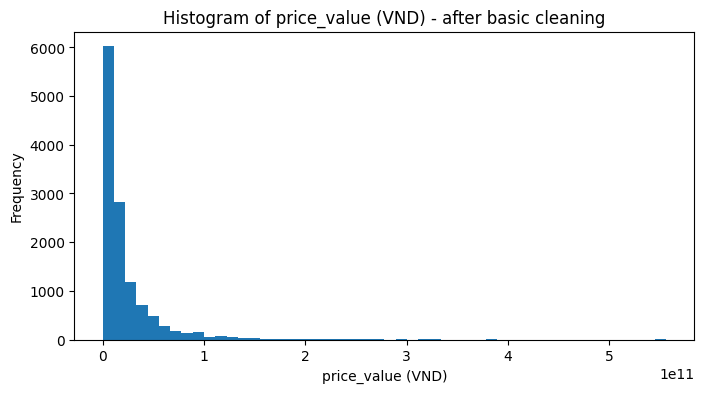

In [14]:
plt.figure(figsize=(8,4))
plt.hist(valid_no_outlier['price_clean_vnd'], bins=50)
plt.title("Histogram of price_value (VND) - after basic cleaning")
plt.xlabel("price_value (VND)")
plt.ylabel("Frequency")
plt.show()

*4. Histogram of area distribution (area).*

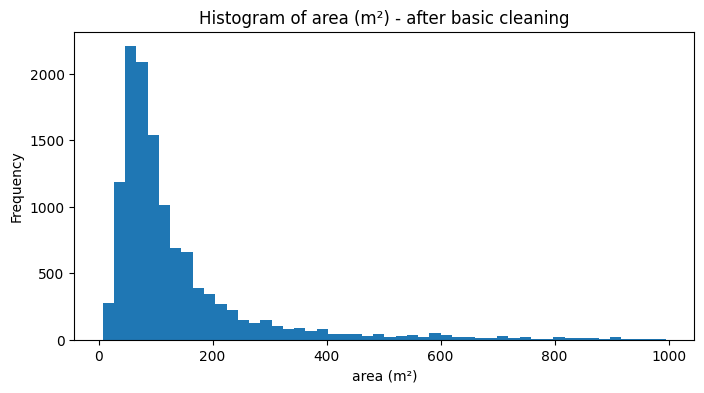

In [15]:
plt.figure(figsize=(8,4))
plt.hist(valid_no_outlier['area_clean'], bins=50)
plt.title("Histogram of area (m²) - after basic cleaning")
plt.xlabel("area (m²)")
plt.ylabel("Frequency")
plt.show()

*5. Compare average price by commune/ward (addressLocality) – show top 15.*

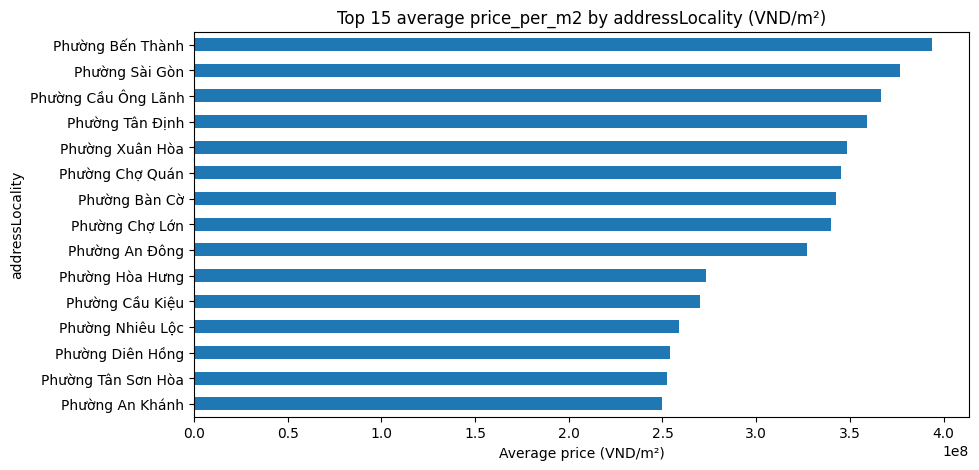

In [16]:
topN = 15
plt.figure(figsize=(10,5))
avg_by_locality.head(topN).sort_values().plot(kind='barh')
plt.title(f"Top {topN} average price_per_m2 by addressLocality (VND/m²)")
plt.xlabel("Average price (VND/m²)")
plt.ylabel("addressLocality")
plt.show()

*6. Compare price per m² by property type (Loại BDS) using boxplot.*

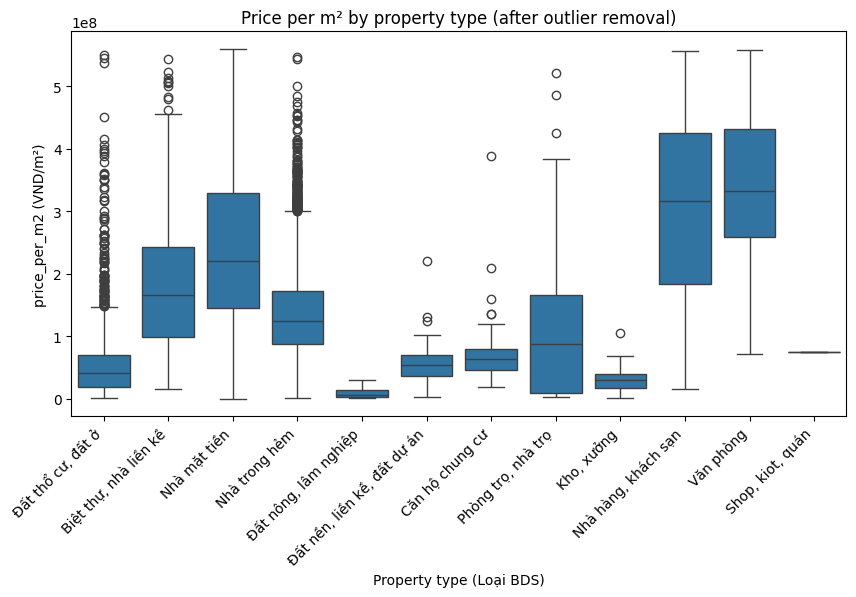

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(data=valid_no_outlier, x='Loại BDS', y='price_per_m2')
plt.xticks(rotation=45, ha='right')
plt.title("Price per m² by property type (after outlier removal)")
plt.xlabel("Property type (Loại BDS)")
plt.ylabel("price_per_m2 (VND/m²)")
plt.show()

*7. Scatter plot between area and price.*

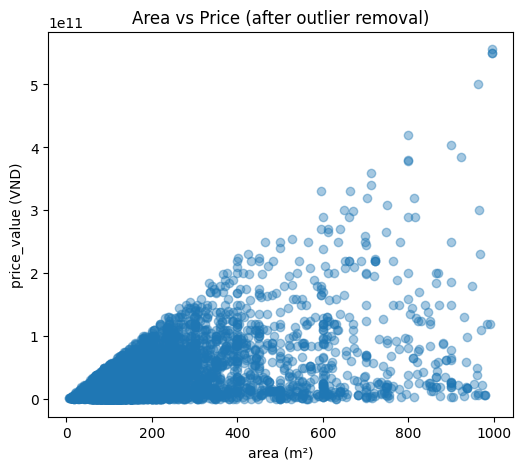

In [18]:
plt.figure(figsize=(6,5))
plt.scatter(valid_no_outlier['area_clean'], valid_no_outlier['price_clean_vnd'], alpha=0.4)
plt.title("Area vs Price (after outlier removal)")
plt.xlabel("area (m²)")
plt.ylabel("price_value (VND)")
plt.show()

*8. Boxplot of price by property type.*

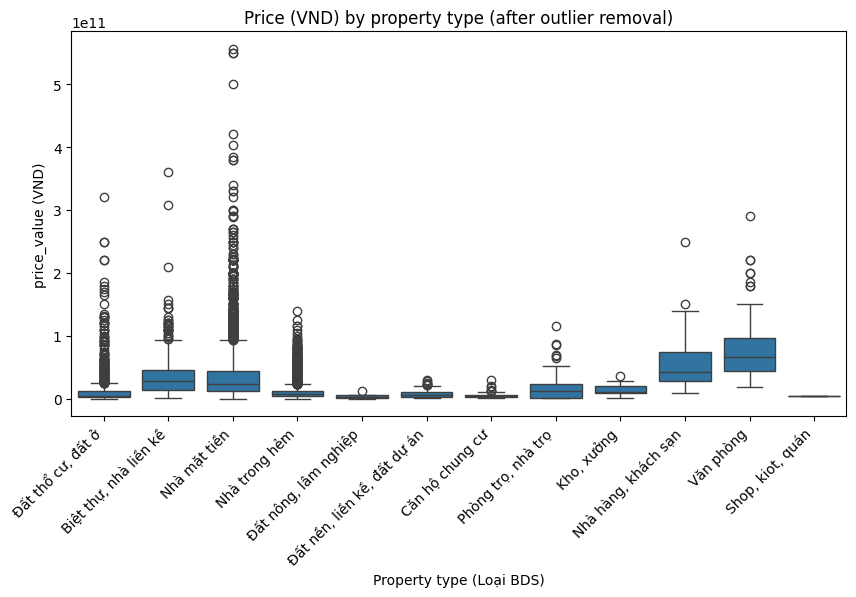

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=valid_no_outlier, x='Loại BDS', y='price_clean_vnd')
plt.xticks(rotation=45, ha='right')
plt.title("Price (VND) by property type (after outlier removal)")
plt.xlabel("Property type (Loại BDS)")
plt.ylabel("price_value (VND)")
plt.show()

## Compare nearby areas within the same old district

We pick an example old district and compare its old wards (average price per m²). You can change `district_example` to another district.

In [20]:
district_example = avg_by_old_district.index[0]  # most expensive old district in the table
district_example

'Quận 1'

In [21]:
ward_prices = (valid_no_outlier[valid_no_outlier['old_district']==district_example]
               .groupby('old_ward')['price_per_m2']
               .mean()
               .sort_values(ascending=False))

ward_prices.head(15)

old_ward
Phường Phạm Ngũ Lão        4.182490e+08
Phường Cô Giang            4.047774e+08
Phường Nguyễn Thái Bình    3.985445e+08
Phường Bến Thành           3.757336e+08
Phường Cầu Ông Lãnh        3.745324e+08
Phường Đa Kao              3.741297e+08
Phường Bến Nghé            3.581837e+08
Phường Nguyễn Cư Trinh     3.531786e+08
Phường Cầu Kho             3.524418e+08
Phường Tân Định            3.478217e+08
Name: price_per_m2, dtype: float64

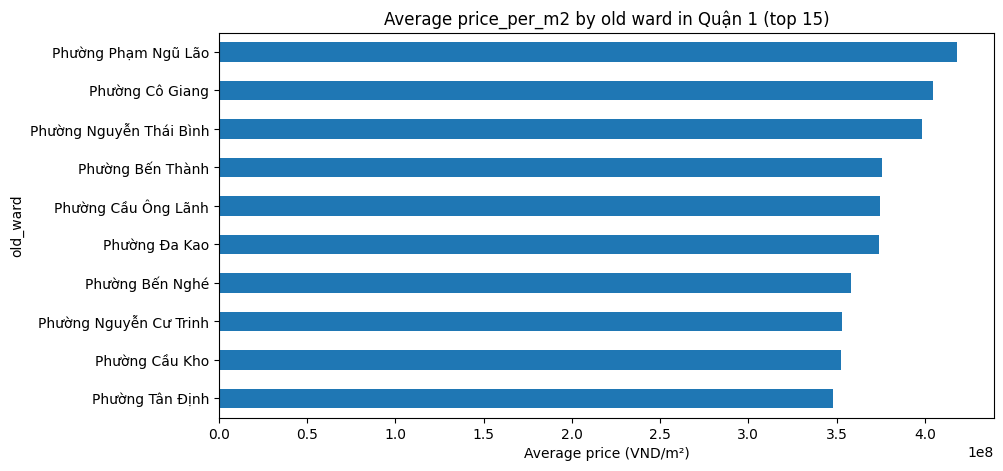

In [22]:
plt.figure(figsize=(10,5))
ward_prices.head(15).sort_values().plot(kind='barh')
plt.title(f"Average price_per_m2 by old ward in {district_example} (top 15)")
plt.xlabel("Average price (VND/m²)")
plt.ylabel("old_ward")
plt.show()

**Answer:** The plot compares average price_per_m2 across nearby wards within the same old district. Large gaps may indicate either real market differences (location/road width/property type) or remaining noise/outliers.

## Additional Cleaning Checks

*16. Check for duplicate records based on Listing ID (Mã tin) and remove duplicates if needed.*

In [23]:
dup_count = df_clean['Mã tin'].duplicated().sum()
dup_count

0

In [24]:
df_dedup = df_clean.drop_duplicates(subset=['Mã tin']).copy()
df_dedup.shape

(13700, 38)

**Answer:** The first output shows the number of duplicated Listing IDs. The second output shows the shape after removing duplicates.